In [217]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import color, io
from skimage.color import rgb2hsv, rgb2gray
import scipy
import cv2
from scipy import ndimage
from skimage.measure import regionprops, label

In [218]:
#Funkcija binarizacije uz pretvaranje slike iz rgb u hsv
def imgBin(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV) #pretvara sliku u hsv
    greenL = np.array([35, 40, 40]) #definise donju i gornju granicu zelene boje u hsv prostoru
    greenH = np.array([85, 255, 255]) 
    mask = cv2.inRange(hsv, greenL, greenH) #pravi masku kod koje svi pikseli koji su zeleni postaju 255(belo), a ostali 0 (crno)

    img_wo_green = 255 - mask #invertovanje maske, belo postaje crno, a crno belo
    grayimg = img_wo_green
    grayimg = ndimage.median_filter(grayimg, size=3)
    T = 0.65 #prag od kog se razlikuju crni i beli pikseli
    m = np.max(grayimg)
    imgbin = np.zeros(np.shape(grayimg))
    imgbin[grayimg>T*m] = 255
    return imgbin


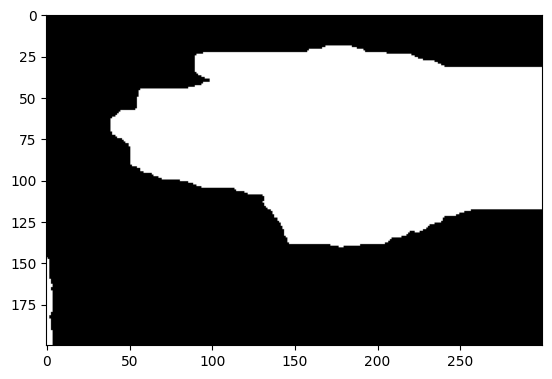

In [219]:
#Rezultat fiksne binarizacije
imgP = io.imread(r"C:\Users\SENKA\Desktop\Rock Paper Scissors\paper\zru6yFR3dqc3SymW.png")
imgP1 = imgBin(imgP)
plt.figure()
plt.imshow(imgP1, cmap = 'gray')
plt.show()

In [220]:

def filterImg(img):
    imgNew = ndimage.median_filter(img, size=3)
    return imgNew

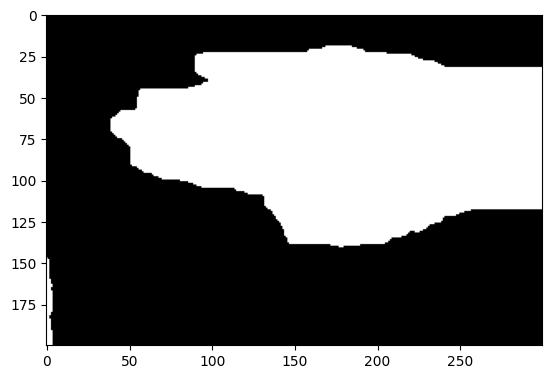

In [221]:
imgP2 = filterImg(imgP1)
plt.figure()
plt.imshow(imgP2, cmap = 'gray')
plt.show()

In [222]:
def removeEdge(img):
    M, N = img.shape
    T = 0.03  # 3% belih piksela

    left = 0
    while left < N-1 and np.count_nonzero(img[:, left]) < T*M:
        left += 1

    right = N-1
    while right > 0 and np.count_nonzero(img[:, right]) < T*M:
        right -= 1

    up = 0
    while up < M-1 and np.count_nonzero(img[up, :]) < T*N:
        up += 1

    down = M-1
    while down > 0 and np.count_nonzero(img[down, :]) < T*N:
        down -= 1

    if left >= right or up >= down:
        print("Nije nađen bounding box – vraćam original")
        return img

    imgNew = img[up:down+1, left:right+1]
    return imgNew


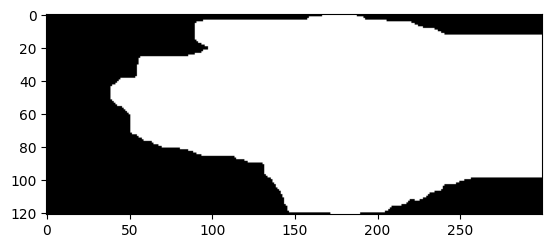

In [223]:
imgP3 = removeEdge(imgP2)
plt.figure()
plt.imshow(imgP3, cmap = 'gray')
plt.show()

In [224]:
def preprocessing(img):
    newImg = imgBin(img)
    newImg = filterImg(newImg)
    newImg = removeEdge(newImg)
    return newImg

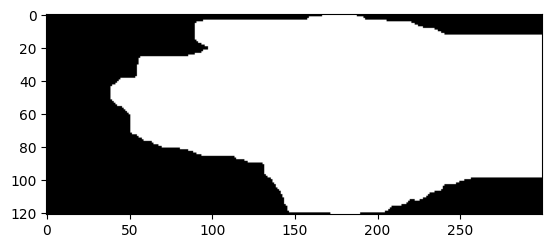

In [225]:
#Testiranje cele predobrade
paper1 = io.imread(r"C:\Users\SENKA\Desktop\Rock Paper Scissors\paper\zru6yFR3dqc3SymW.png")
rock1 = io.imread(r"C:\Users\SENKA\Desktop\Rock Paper Scissors\rock\zdNuxse3BvJK3s6Q.png")
scissors1 = io.imread(r"C:\Users\SENKA\Desktop\Rock Paper Scissors\scissors\3bkC6JAPog7xX9WO.png")

ppImg = preprocessing(paper1)
plt.figure()
plt.imshow(ppImg, cmap = 'gray')
plt.show()


In [ ]:
from skimage.measure import perimeter

def extractFeatures(img):

    X = np.zeros((5,)) 
    area = np.count_nonzero(img)
    X1 = area 

    per = perimeter(img == 255,neighborhood=8)
    X2 = per

    X3 = area / per
    #odnos povrsine i obima

    if per > 0: #kompaktnost
        X4 = (4 * np.pi * area) / (per ** 2)
    else:
        X4 = 0

    M, N = img.shape
    left = np.sum(img[:, :N//2] == 255)
    right = np.sum(img[:, N//2:] == 255)

    eps = 1e-6
    X5 = left / (right + eps) #odnos broja piksela koji su levo od centra i koji su desno


    X[0] = X1
    X[1] = X2
    X[2] = X3
    X[3] = X4
    X[4] = X5

   
   
    return X
    

In [227]:
import os
#fja za ekstrakciju obelezja za sve podatke jedne klase
def patternFeatures(folder, n_img):  #folder i broj slika u folderu

    i = 0
    features = np.zeros((5, n_img))

    for filename in os.listdir(folder):
        image_path = os.path.join(folder, filename)
        img = io.imread(image_path)
        imgbin = preprocessing(img)
        features[:, i] = extractFeatures(imgbin)
        i += 1

    return features

#features broj obelezja x broj slika

In [228]:
#Definisanje foldera sa podacim
folderRock = r"C:\Users\SENKA\Desktop\Rock Paper Scissors\rock"
folderPaper = r"C:\Users\SENKA\Desktop\Rock Paper Scissors\paper"
folderScissors = r"C:\Users\SENKA\Desktop\Rock Paper Scissors\scissors"
extensions = ('.jpg', '.jpeg', '.png')

In [229]:
#Prebrojavanje slika u folderima
import os

def imgCnt(folder):
    num = 0
    for file in os.listdir(folder):
        if file.lower().endswith(extensions):
         num += 1
    return num

In [230]:

rockNum = imgCnt(folderRock)
paperNum = imgCnt(folderPaper)
scissorsNum = imgCnt(folderScissors)

rock = patternFeatures(folderRock,rockNum)
paper = patternFeatures(folderPaper,paperNum)
scissors = patternFeatures(folderScissors,scissorsNum)

In [231]:
def scaling(feature):
    #feature broj obelezja x broj slika

    f_max = np.max(feature, axis = 1).T.reshape(-1, 1)
    f_min = np.min(feature, axis = 1).T.reshape(-1, 1)
    f_scaled = (feature - f_min) / (f_max - f_min)
    

    return f_scaled

In [232]:

paperS = scaling(paper).T
rockS = scaling(rock).T
scissorsS = scaling(scissors).T
datap = np.concatenate((paperS, np.zeros((paperS.shape[0],1))), axis = 1)
datar = np.concatenate((rockS, np.ones((rockS.shape[0],1))), axis = 1)
datas = np.concatenate((scissorsS, 2 * np.ones((scissorsS.shape[0],1))), axis = 1)
data = np.concatenate((datap,datar,datas))

#0 - papir
#1 - kamen
#2 - makaze


In [233]:
print(np.shape(data))


(2131, 6)


In [234]:
#Podela na trenirajuci i test skup
from sklearn.model_selection import train_test_split

X = data[:, :-1]
y = data[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)


In [235]:
def gaussian_pdf(X, M, S):
    detS = np.linalg.det(S)
    invS = np.linalg.inv(S)
    f = 1/(2*np.pi*detS**0.5)*np.exp(-0.5*(X - M).T@invS@(X - M))
    return f[0, 0]

In [236]:
#Potrebni parametri
M1 = np.mean(X_train[y_train == 0], axis = 0).reshape(-1,1)
M2 = np.mean(X_train[y_train == 1], axis = 0).reshape(-1,1)
M3 = np.mean(X_train[y_train == 2], axis = 0).reshape(-1,1)
S1 = np.cov(X_train[y_train == 0].T)
S2 = np.cov(X_train[y_train == 1].T)
S3 = np.cov(X_train[y_train == 2].T)
P1 = len(paperS[:,0])/(len(paperS[:,0])+len(rockS[:,0])+len(scissorsS[:,0]))
P2 = len(rockS[:,0])/(len(paperS[:,0])+len(rockS[:,0])+len(scissorsS[:,0]))
P3 = len(scissorsS[:,0])/(len(paperS[:,0])+len(rockS[:,0])+len(scissorsS[:,0]))

In [237]:
def classifyMul(X):

    res = np.zeros(X.shape[0], dtype=int)

    for i in range(X.shape[0]):
        x = X[i].reshape(-1,1)

        g1 = P1 * gaussian_pdf(x, M1, S1)
        g2 = P2 * gaussian_pdf(x, M2, S2)
        g3 = P3 * gaussian_pdf(x, M3, S3)

        res[i] = np.argmax([g1, g2, g3]) #vraca indeks elementa sa najvecom vrednoscu

    return res


Tacnost: 0.9859
Preciznost (macro): 0.9855
Osetljivost (macro): 0.9857
F1-skor (macro): 0.9856
Balansirana tacnost: 0.9857


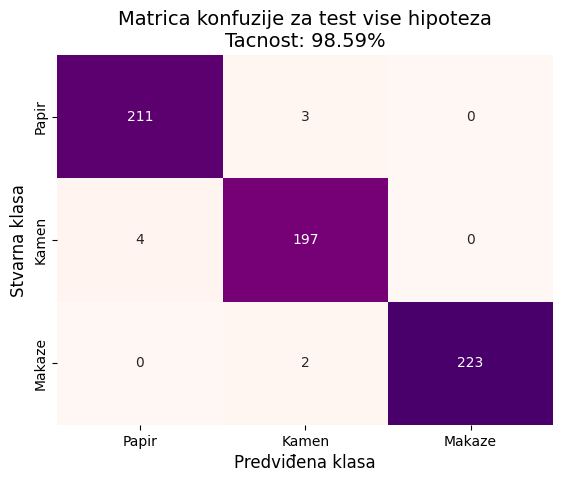

In [238]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)


y_pred = classifyMul(X_test)
cm = confusion_matrix(y_test, y_pred)

ACC = accuracy_score(y_test, y_pred)
P = precision_score(y_test, y_pred, average='macro') #racuna preciznost za svaku klasu, pa onda usrednji sve 3
R = recall_score(y_test, y_pred, average='macro')
F1 = f1_score(y_test, y_pred, average='macro')
BA = balanced_accuracy_score(y_test, y_pred)

print(f"Tacnost: {ACC:.4f}")
print(f"Preciznost (macro): {P:.4f}")
print(f"Osetljivost (macro): {R:.4f}")
print(f"F1-skor (macro): {F1:.4f}")
print(f"Balansirana tacnost: {BA:.4f}")

sns.heatmap(
    cm, 
    annot = True,
    fmt = 'd', 
    cbar = False, 
    cmap="RdPu",
    xticklabels=['Papir', 'Kamen', 'Makaze'],
    yticklabels=['Papir', 'Kamen', 'Makaze']
)
plt.title(f'Matrica konfuzije za test vise hipoteza\nTacnost: {ACC*100:.2f}%', fontsize = 14)
plt.xlabel('Predviđena klasa', fontsize = 12)
plt.ylabel('Stvarna klasa', fontsize = 12)
plt.show()



In [239]:
#Trazenje 2 najinformativnija obelezja

def plotFeatureHist(X1, X2, featureidx, label1, label2, bins=20):
    
    plt.figure()
    plt.hist(X1[:, featureidx], bins=bins, alpha=0.6, label=label1)
    plt.hist(X2[:, featureidx], bins=bins, alpha=0.6, label=label2)

    plt.xlabel(f'Obeležje f{featureidx}')
    plt.ylabel('Broj uzoraka')
    plt.title(f'Histogram obeležja {featureidx}')
    plt.legend()
    plt.grid(True)
    plt.show()


In [258]:
def plotClassAndFeatures(class1, class2, feature1, feature2, X_test,y_test):
    K1 = np.vstack((X_test[y_test == class1, feature1], X_test[y_test == class1, feature2])).T
    K2 = np.vstack((X_test[y_test == class2, feature1], X_test[y_test == class2, feature2])).T
    plt.figure()
    plt.plot(K1[:,0], K1[:,1], 'o')
    plt.plot(K2[:,0], K2[:,1], '*')
    if class1==0:
        str1 = 'Paper'
    elif class1==1:
        str1 = 'Rock'
    else:
        str1 = 'Scissors'
    if class2==0:
        str2 = 'Paper'
    elif class2==1:
        str2 = 'Rock'
    else:
        str2 = 'Scissors'
    plt.title(f'Klase {str1} i {str2}')
    plt.xlabel(f'Obelezje {feature1} ')
    plt.ylabel(f'Obelezje {feature2} ')
    plt.grid()
    plt.show()

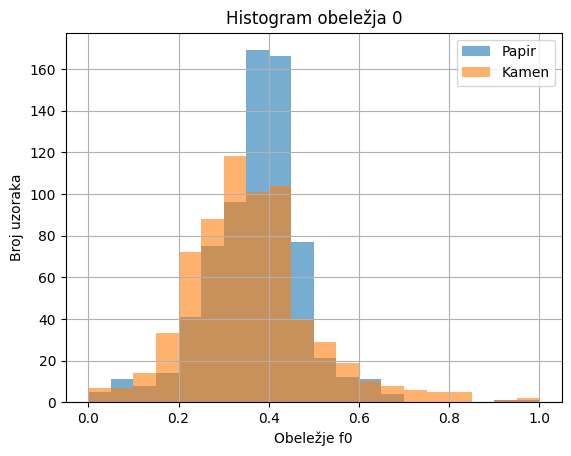

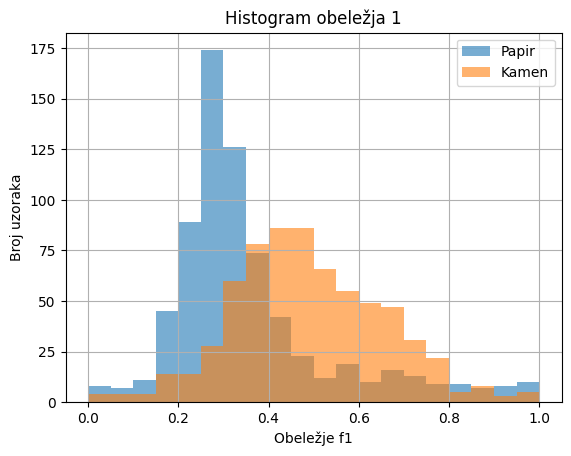

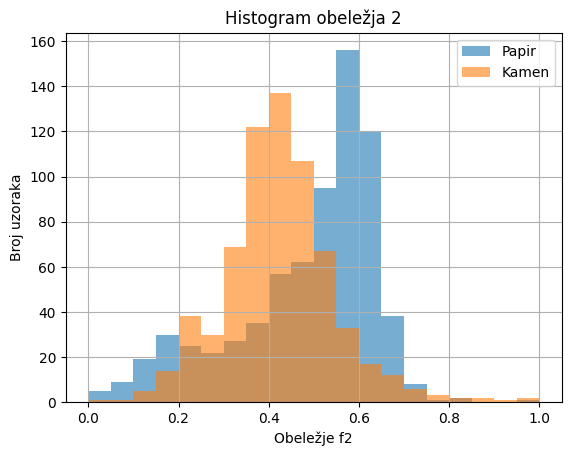

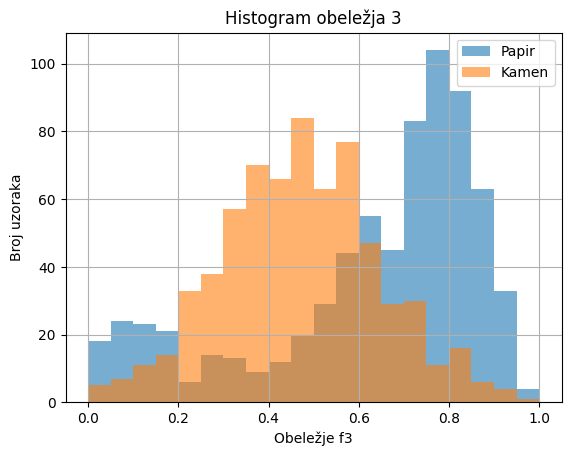

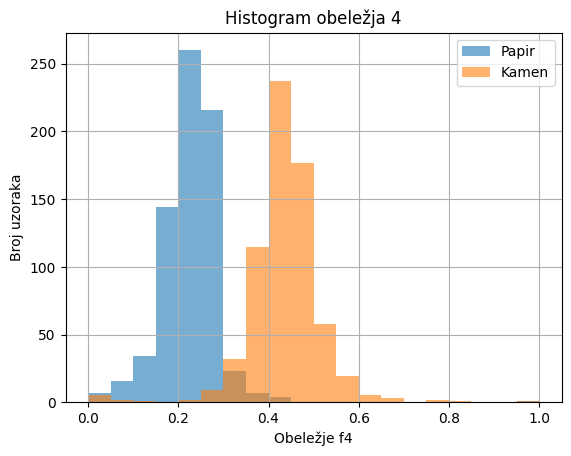

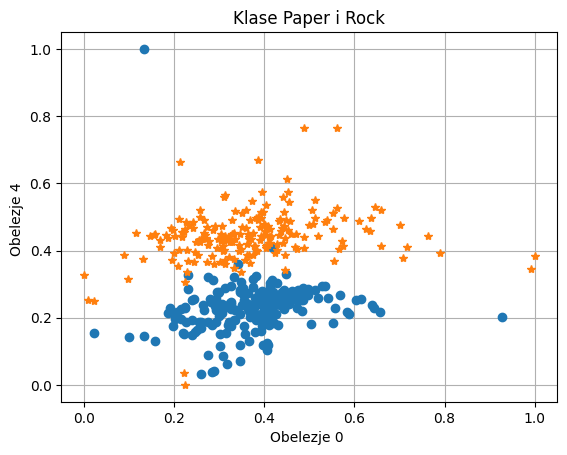

'\nplotClassAndFeatures(0,1,0,1,X_test,y_test)\nplotClassAndFeatures(0,1,0,2,X_test,y_test)\nplotClassAndFeatures(0,1,0,3,X_test,y_test)\nplotClassAndFeatures(0,1,0,4,X_test,y_test)\nplotClassAndFeatures(0,1,1,3,X_test,y_test)\nplotClassAndFeatures(0,1,1,2,X_test,y_test)\nplotClassAndFeatures(0,1,1,4,X_test,y_test)\nplotClassAndFeatures(0,1,2,3,X_test,y_test)\nplotClassAndFeatures(0,1,2,4,X_test,y_test)\n\nplotClassAndFeatures(0,2,0,2,X_test,y_test)\nplotClassAndFeatures(0,2,0,3,X_test,y_test)\nplotClassAndFeatures(0,2,0,4,X_test,y_test)\nplotClassAndFeatures(0,2,1,3,X_test,y_test)\nplotClassAndFeatures(0,2,1,2,X_test,y_test)\nplotClassAndFeatures(0,2,1,4,X_test,y_test)\nplotClassAndFeatures(0,2,2,3,X_test,y_test)\nplotClassAndFeatures(0,2,2,4,X_test,y_test)\n\nplotClassAndFeatures(2,1,0,2,X_test,y_test)\nplotClassAndFeatures(2,1,0,3,X_test,y_test)\nplotClassAndFeatures(2,1,0,4,X_test,y_test)\nplotClassAndFeatures(2,1,1,3,X_test,y_test)\nplotClassAndFeatures(2,1,1,2,X_test,y_test)\nplo

In [259]:
    #0 - povrsina
    #1 - obim
    #2 - devijacija belina i crnina po horizontali
    #3 - odnos beline u levoj i desnoj polovini slike
plotFeatureHist(paperS, rockS, 0, 'Papir', 'Kamen')
plotFeatureHist(paperS, rockS, 1, 'Papir', 'Kamen')
plotFeatureHist(paperS, rockS, 2, 'Papir', 'Kamen')
plotFeatureHist(paperS, rockS, 3, 'Papir', 'Kamen')
plotFeatureHist(paperS, rockS, 4, 'Papir', 'Kamen')

plotClassAndFeatures(0,1,0,4,X_test,y_test)#najbolje
'''
plotClassAndFeatures(0,1,0,1,X_test,y_test)
plotClassAndFeatures(0,1,0,2,X_test,y_test)
plotClassAndFeatures(0,1,0,3,X_test,y_test)
plotClassAndFeatures(0,1,0,4,X_test,y_test)
plotClassAndFeatures(0,1,1,3,X_test,y_test)
plotClassAndFeatures(0,1,1,2,X_test,y_test)
plotClassAndFeatures(0,1,1,4,X_test,y_test)
plotClassAndFeatures(0,1,2,3,X_test,y_test)
plotClassAndFeatures(0,1,2,4,X_test,y_test)

plotClassAndFeatures(0,2,0,2,X_test,y_test)
plotClassAndFeatures(0,2,0,3,X_test,y_test)
plotClassAndFeatures(0,2,0,4,X_test,y_test)
plotClassAndFeatures(0,2,1,3,X_test,y_test)
plotClassAndFeatures(0,2,1,2,X_test,y_test)
plotClassAndFeatures(0,2,1,4,X_test,y_test)
plotClassAndFeatures(0,2,2,3,X_test,y_test)
plotClassAndFeatures(0,2,2,4,X_test,y_test)

plotClassAndFeatures(2,1,0,2,X_test,y_test)
plotClassAndFeatures(2,1,0,3,X_test,y_test)
plotClassAndFeatures(2,1,0,4,X_test,y_test)
plotClassAndFeatures(2,1,1,3,X_test,y_test)
plotClassAndFeatures(2,1,1,2,X_test,y_test)
plotClassAndFeatures(2,1,1,4,X_test,y_test)
plotClassAndFeatures(2,1,2,3,X_test,y_test)
plotClassAndFeatures(2,1,2,4,X_test,y_test)'''


In [242]:
#Parametarska klasifikacija - Linearni klasifikator na bazi zeljenih ulaza
def desiredOutput(K1, K2, Gamma):
    N1 = K1.shape[0]
    N2 = K2.shape[0]
    U1 = np.concatenate((-K1,-np.ones((N1,1))), axis = 1)
    U2 = np.concatenate((K2,np.ones((N2,1))), axis = 1)
    U = np.concatenate((U1,U2), axis = 0)
    W = np.linalg.inv(U.T@U)@U.T@Gamma
    return U,W



In [243]:
K1 = np.vstack((X_train[y_train == 0, 0], X_train[y_train == 0, 4])).T
K2 = np.vstack((X_train[y_train == 1, 0], X_train[y_train == 1, 4])).T
print(np.shape(K1)) 

(498, 2)


In [244]:

inputs = np.vstack((K1, K2))
K1test = np.vstack((X_test[y_test == 0, 0], X_test[y_test == 0, 4])).T
K2test = np.vstack((X_test[y_test == 1, 0], X_test[y_test == 1, 4])).T
Gamma = np.vstack((
    np.ones((K1.shape[0],1)),
    np.ones((K2.shape[0],1))
))
test = np.vstack((K1test,K2test))
outputs = np.zeros(len(test))

U, W = desiredOutput(K1,K2,Gamma)

for i, x in enumerate(test):
    #i redni broj, x sadrzaj inputs na tom rednom broju, 1d niz dimenzije 2 tj koliko ima obelezja
    x = x.reshape(1,-1)
    
    g = (x @ W[0:2]).item() + W[2,0] #item pretvara u skalar

    if g< 0: 
       outputs[i] = 0
    else:      
        outputs[i] = 1



Tacnost: 0.9831
Preciznost (macro): 0.9830
Osetljivost (macro): 0.9833
F1-skor (macro): 0.9831
Balansirana tacnost: 0.9833


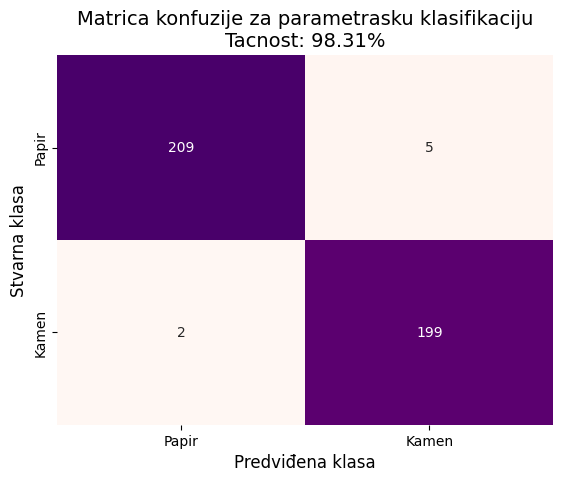

In [264]:
y_true = np.hstack((
    np.zeros(len(K1test)),
    np.ones(len(K2test))
))
cm = confusion_matrix(y_true, outputs)
sns.heatmap(
    cm, 
    annot = True,
    fmt = 'd', 
    cmap = 'RdPu', 
    cbar = False, 

    xticklabels=['Papir', 'Kamen'],
    yticklabels=['Papir', 'Kamen']
)
ACC = accuracy_score(y_true,outputs)
P = precision_score(y_true, outputs, average='macro') #racuna preciznost za svaku klasu, pa onda usrednji sve 3
R = recall_score(y_true, outputs, average='macro')
F1 = f1_score(y_true, outputs, average='macro')
BA = balanced_accuracy_score(y_true, outputs)

print(f"Tacnost: {ACC:.4f}")
print(f"Preciznost (macro): {P:.4f}")
print(f"Osetljivost (macro): {R:.4f}")
print(f"F1-skor (macro): {F1:.4f}")
print(f"Balansirana tacnost: {BA:.4f}")
plt.title(f'Matrica konfuzije za parametrasku klasifikaciju\nTacnost: {ACC*100:.2f}%', fontsize = 14)
plt.xlabel('Predviđena klasa', fontsize = 12)
plt.ylabel('Stvarna klasa', fontsize = 12)
plt.show()

In [246]:
def decision_line(V, V0, x):
    v1 = V[0,0]
    v2 = V[1,0]
    if v2 != 0:
        res = (V0 - v1 * x) / v2
        flag = False
    else:
        res = V0/v1
        flag = True
    return flag, res
    


In [262]:
def plot_decision_line(flag, res, xvals, yvals,label):
    if flag:  #vertikalna
        plt.plot(res * np.ones_like(yvals), yvals,linestyle = '--',color = 'k', label = label)
    else:   
        plt.plot(xvals, res,linestyle = '--', label = label,color = 'k')


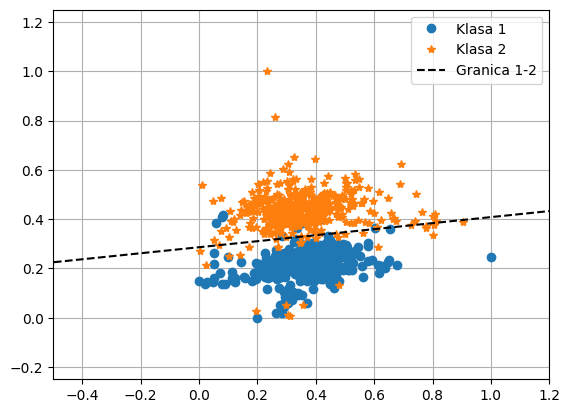

In [263]:
xvals = np.arange(-10,25,0.1)
yvals = np.arange(-10,10,0.1)

flag12,res12 = decision_line(W[0:2], -W[2,0], xvals)

K1all = np.vstack((K1, K1test))

K2all = np.vstack((K2, K2test))


plt.figure()
plt.plot(K1[:,0], K1[:,1], 'o', label = 'Klasa 1')
plt.plot(K2[:,0], K2[:,1], '*', label = 'Klasa 2')

plot_decision_line(flag12, res12, xvals, yvals,label = 'Granica 1-2')

plt.legend()
plt.ylim([-0.25,1.25])
plt.xlim([-0.5,1.2])
plt.grid()
plt.show()


In [249]:
#Kvadratni klasifikator na bazi zeljenih izlaza
def quad_features(X):
    x1 = X[:, 0]
    x2 = X[:, 1]

    return np.column_stack((
        x1**2,
        x2**2,
        x1*x2,
        x1,
        x2,
        np.ones(len(X))
    ))


In [250]:
def desiredOutputQuadratic(K1, K2, Gamma):
    Phi1 = quad_features(K1)
    Phi2 = quad_features(K2)

    Phi = np.vstack((Phi1, Phi2))
    W = np.linalg.pinv(Phi) @ Gamma 
    #funkcija za pseudo inverz 

    return W


In [251]:
Gamma = np.vstack((
    -np.ones((K1.shape[0], 1)),
     np.ones((K2.shape[0], 1))
))

Wq = desiredOutputQuadratic(K1, K2, Gamma)


In [252]:
outputs = np.zeros(len(test), dtype=int)

Phi_test = quad_features(test)

for i in range(len(test)):
    g = Phi_test[i] @ Wq
    outputs[i] = 0 if g < 0 else 1


Tacnost: 0.9831
Preciznost (macro): 0.9830
Osetljivost (macro): 0.9833
F1-skor (macro): 0.9831
Balansirana tacnost: 0.9833


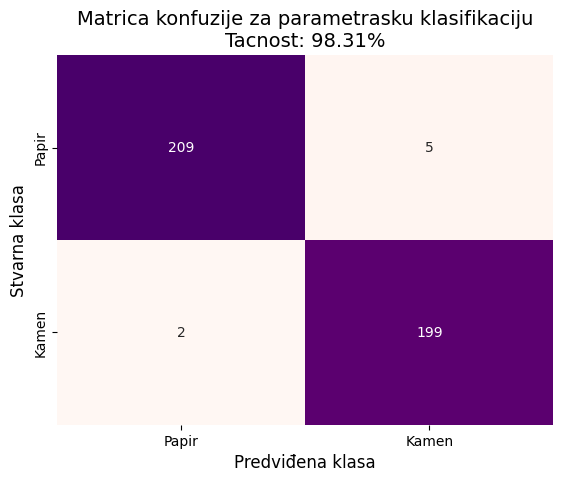

In [265]:
y_test01 = np.hstack((
    np.zeros(len(K1test)),
    np.ones(len(K2test))
))

cm = confusion_matrix(y_test01, outputs)
sns.heatmap(
    cm, 
    annot = True,
    fmt = 'd', 
    cmap = 'RdPu', 
    cbar = False, 

    xticklabels=['Papir', 'Kamen'],
    yticklabels=['Papir', 'Kamen']
)
ACC = accuracy_score(y_test01,outputs)
P = precision_score(y_test01, outputs, average='macro') #racuna preciznost za svaku klasu, pa onda usrednji sve 3
R = recall_score(y_test01, outputs, average='macro')
F1 = f1_score(y_test01, outputs, average='macro')
BA = balanced_accuracy_score(y_test01, outputs)

print(f"Tacnost: {ACC:.4f}")
print(f"Preciznost (macro): {P:.4f}")
print(f"Osetljivost (macro): {R:.4f}")
print(f"F1-skor (macro): {F1:.4f}")
print(f"Balansirana tacnost: {BA:.4f}")
plt.title(f'Matrica konfuzije za parametrasku klasifikaciju\nTacnost: {ACC*100:.2f}%', fontsize = 14)
plt.xlabel('Predviđena klasa', fontsize = 12)
plt.ylabel('Stvarna klasa', fontsize = 12)
plt.show()


In [254]:
# Granice za crtanje
x1_min, x1_max = test[:,0].min() - 1, test[:,0].max() + 1
x2_min, x2_max = test[:,1].min() - 1, test[:,1].max() + 1

xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300)
)

grid = np.column_stack((
    xx1.ravel(),
    xx2.ravel()
))

grid_q = quad_features(grid)
g_vals = grid_q @ Wq
g_vals = g_vals.reshape(xx1.shape)


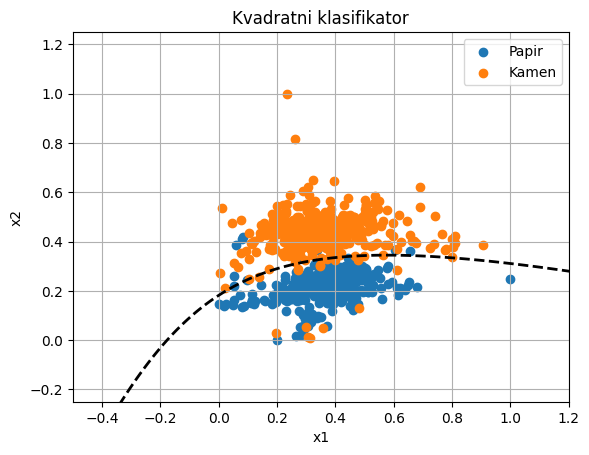

In [255]:
plt.figure()

plt.contour(xx1, xx2, g_vals, levels=[0], colors='black',linestyles='--', linewidths=2)

plt.scatter(K1[:,0], K1[:,1], label='Papir')
plt.scatter(K2[:,0], K2[:,1], label='Kamen')

plt.xlabel('x1')
plt.ylabel('x2')
plt.ylim([-0.25,1.25])
plt.xlim([-0.5,1.2])
plt.title('Kvadratni klasifikator')
plt.legend()
plt.grid(True)
plt.show()
